CTR & CPA calculated successfully
     Ad_group       CTR        CPA
0  ad_group_3  0.013697  26.523243
1  ad_group_4  0.029084  55.735273
2   AdGroup_1  0.017358   0.666000
3  ad_group_3  0.036805  67.944878
4  ad_group_2  0.082397  97.533333

Optimization Recommendations:
     Ad_group       CTR         CPA Optimization_Action
0  ad_group_3  0.013697   26.523243    Improve Creative
1  ad_group_4  0.029084   55.735273    Improve Creative
2   AdGroup_1  0.017358    0.666000    Improve Creative
3  ad_group_3  0.036805   67.944878    Improve Creative
4  ad_group_2  0.082397   97.533333  Reduce Bid / Pause
5  ad_group_3  0.012118   25.567568    Improve Creative
6  ad_group_1  0.051526   55.511321        Scale Budget
7  ad_group_2  0.035322   26.761571    Improve Creative
8  AdGroup_22  0.072623    7.966667        Scale Budget
9  ad_group_5  0.056656  103.041304  Reduce Bid / Pause


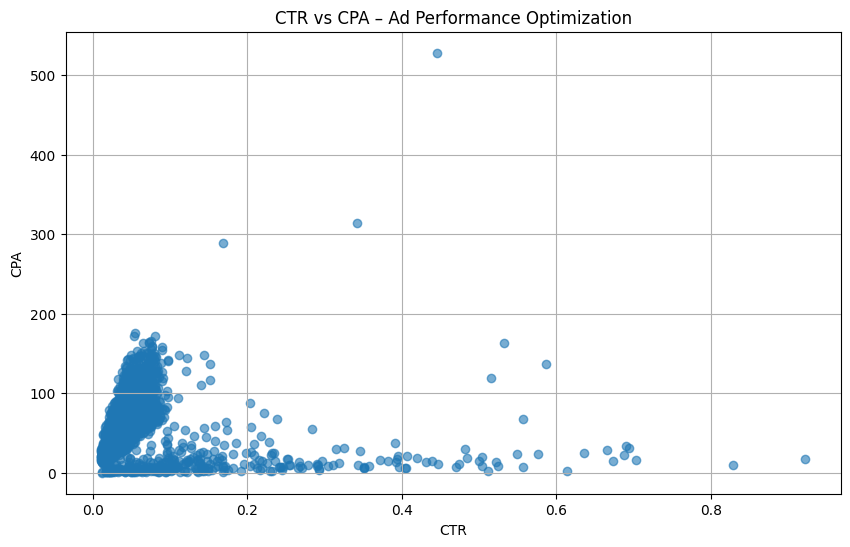

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Reload dataset (guarantees 'data' exists)
file_path = r"C:\Users\Win 10\Downloads\synthetic_data_groups.csv"
data = pd.read_csv(file_path)

# Recompute Cost (required for CPA)
data['Cost'] = data['Clicked'] * data['Avg_cost_per_click']

# Compute CTR & CPA
data['CTR'] = data['Clicked'] / data['Shown'].replace(0, np.nan)
data['CPA'] = data['Cost'] / data['Converted'].replace(0, np.nan)

#  Clean invalid values
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data[['CTR', 'CPA']] = data[['CTR', 'CPA']].fillna(0)

print("CTR & CPA calculated successfully")
print(data[['Ad_group', 'CTR', 'CPA']].head())

#  Optimization thresholds
ctr_threshold = data['CTR'].median()
cpa_threshold = data['CPA'].quantile(0.75)

#  Optimization actions
data['Optimization_Action'] = np.where(
    data['CTR'] < ctr_threshold, 'Improve Creative',
    np.where(
        data['CPA'] > cpa_threshold, 'Reduce Bid / Pause',
        'Scale Budget'
    )
)

print("\nOptimization Recommendations:")
print(data[['Ad_group', 'CTR', 'CPA', 'Optimization_Action']].head(10))

#  CTR vs CPA Visualization
plt.figure(figsize=(10, 6))
plt.scatter(data['CTR'], data['CPA'], alpha=0.6)
plt.xlabel('CTR')
plt.ylabel('CPA')
plt.title('CTR vs CPA – Ad Performance Optimization')
plt.grid()
plt.show()


In [2]:
#Identify Ads Needing CTR Improvement

In [3]:
# --- Improve CTR ---

ctr_threshold = data['CTR'].median()

low_ctr_ads = data[data['CTR'] < ctr_threshold]

print("Ads needing CTR improvement (below median CTR):")
print(low_ctr_ads[['Ad_group', 'CTR']].head())


Ads needing CTR improvement (below median CTR):
     Ad_group       CTR
0  ad_group_3  0.013697
1  ad_group_4  0.029084
2   AdGroup_1  0.017358
3  ad_group_3  0.036805
5  ad_group_3  0.012118


In [4]:
#Identify Ads with High CPA (Reduce Cost)

In [5]:
# --- Reduce CPA ---

cpa_threshold = data['CPA'].quantile(0.75)

high_cpa_ads = data[data['CPA'] > cpa_threshold]

print("Ads with high CPA (top 25% costliest):")
print(high_cpa_ads[['Ad_group', 'CPA']].head())


Ads with high CPA (top 25% costliest):
      Ad_group         CPA
4   ad_group_2   97.533333
9   ad_group_5  103.041304
20  ad_group_5  109.301935
24  ad_group_3  109.596098
25  ad_group_3  150.816364


In [6]:
#Budget Reallocation Using ROAS

In [9]:
# Ensure ROAS exists (SAFE FIX)

data['Cost'] = data['Clicked'] * data['Avg_cost_per_click']

data['ROAS'] = data['Total_revenue'] / data['Cost']

# Clean invalid values
data['ROAS'] = data['ROAS'].replace([np.inf, -np.inf], np.nan).fillna(0)

print("ROAS column created successfully")
print(data[['Ad_group', 'ROAS']].head())


ROAS column created successfully
     Ad_group        ROAS
0  ad_group_3    1.194292
1  ad_group_4    0.304080
2   AdGroup_1  314.757883
3  ad_group_3    0.383051
4  ad_group_2    0.178753


In [10]:
# --- Scale High Performing Ads ---

roas_by_adgroup = (
    data.groupby('Ad_group')['ROAS']
    .mean()
    .sort_values(ascending=False)
)

print("High ROAS Ad Groups (Increase Budget):")
print(roas_by_adgroup.head(3))


High ROAS Ad Groups (Increase Budget):
Ad_group
AdGroup_22    46.694509
AdGroup_30    43.278902
AdGroup_1     39.205124
Name: ROAS, dtype: float64
